In [1]:
import matplotlib.pyplot as plt
import numpy as np

## Άσκηση - Ο μετασχηματισμός Laplace αριθμητικά

Πλέον γνωρίζετε καλά το μετασχηματισμό Laplace και τον αντίστροφο του (δηλ. τις τεχνικές με τις οποίες μπορούμε να τον αντιστρέψουμε, καθώς δε χρησιμοποιήσαμε τον ορισμό του αντιστρόφου μετασχ. Laplace). Ας δείξουμε σε αυτήν την άσκηση ότι μπορούμε να δουλέψουμε αριθμητικά με το μετασχ. Laplace και τον αντίστροφό του, με κάπως παρόμοιο τρόπο με το μετασχ. Fourier και τον αντίστροφό του.

Ξέρετε ότι

$$X(s) = X(\sigma + j2\pi f) = \int_{-\infty}^{+\infty}x(t)e^{-st}dt = \int_{-\infty}^{+\infty}x(t)e^{-\sigma t}e^{-j2\pi ft}dt$$

Ας θεωρήσουμε το γνωστό ζεύγος

$$x(t) = e^{2t}u(t) \longleftrightarrow X(s) = \frac{1}{s-2}, \: \: \Re\{s\} = \sigma > 2$$

Ο μετασχηματισμός μπορεί να γραφεί ως

$$X(\sigma + j2\pi f) = \frac{1}{\sigma+ j2\pi f - 2} = \frac{1}{(\sigma - 2) + j2\pi f}, \: \: \sigma > 2$$

Αυτό το σήμα δεν έχει μετασχηματισμό Fourier καθώς ο φανταστικός άξονας $\sigma = 0$ δεν περιλαμβάνεται στο πεδίο σύγκλισης $\sigma > 2$. Όπως δείξαμε όμως στην πρώτη διάλεξη περί μετασχ. Laplace, "μπορούμε να το κάνουμε να έχει" 😃!

Ας ορίσουμε το σήμα

$$\hat{x}(t) = e^{2t}u(t)e^{-\sigma t} = e^{(2-\sigma)t}u(t), \: \: \sigma > 2$$

Αυτό το σήμα έχει μετασχ. Fourier

$$\hat{X}(f) = \int_{-\infty}^{+\infty}\hat{x}(t)e^{-j2\pi ft}dt = \int_{-\infty}^{+\infty}e^{(2-\sigma)t}u(t)e^{-j2\pi ft}dt = \int_{0}^{+\infty}e^{(2-\sigma)t}e^{-j2\pi ft}dt = \int_{0}^{+\infty}e^{-(\sigma-2)t}e^{-j2\pi ft}dt = \frac{1}{(\sigma-2) + j2\pi f}, \: \: \sigma > 2$$

και αντίστροφο μετασχ. Fourier

$$\hat{x}(t) = \int_{-\infty}^{+\infty}\hat{X}(f)e^{j2\pi ft}dt = \int_{-\infty}^{+\infty}\frac{1}{(\sigma-2) + j2\pi f}e^{j2\pi ft}df, \: \: \sigma > 2$$

Όμως εμάς μας νοιάζει το σήμα $x(t)$, όχι το $\hat{x}(t)$!

Μπορούμε να βρούμε το ζητούμενο σήμα πολλαπλασιάζοντας το $\hat{x}(t)$ με $e^{\sigma t}$, δηλ.

$$x(t) = \hat{x}(t)e^{\sigma t} = e^{2t}u(t)e^{-\sigma t} e^{\sigma t} = e^{2t}u(t)$$

και αντίστοιχα

$$x(t) = \hat{x}(t)e^{\sigma t} = e^{\sigma t}\int_{-\infty}^{+\infty}\frac{1}{(\sigma - 2) + j2\pi f}e^{j2\pi ft}df = \int_{-\infty}^{+\infty}\frac{e^{\sigma t}}{(\sigma - 2) + j2\pi f}e^{j2\pi ft}df, \: \: \sigma > 2$$

Ας χρησιμοποιήσουμε τα παραπάνω για να δούμε ότι πράγματι ο μετασχ. Laplace δουλεύει! Ας θέσουμε μια τιμή για το $\sigma > 2$. Έστω $\sigma = 3$. 

In [2]:
# Παράμετρος α
a = 2

# Βήμα στο χρόνο
dt = 0.01
# Άξονας χρόνου [-2,1] s
t = np.arange(-2, 1 + dt, dt)

# Βήμα στη συχνότητα
df = 0.01
# Άξονας συχνότητας [-100,100] Hz
f = np.arange(-100, 100 + df, df)

# Σήμα (0 για t < 0, exp(at) για t > 0)
x = np.where(t <= 0, 0, np.exp(a * t))

# Επιλογή μιας τιμής του σ (έστω 3, όπως αναφέραμε)
sigma = 3

Τώρα μπορούμε να χρησιμοποιήσουμε το μετασχ. Laplace στην "ανοιχτή" μορφή του (με $s=\sigma + j2\pi f$) και να ανακατασκευάσουμε το σήμα στο χρόνο σύμφωνα με την τελευταία σχέση για το σήμα $x(t)$ που καταλήξαμε παραπάνω!

In [3]:
# Μετασχηματισμός Laplace για σ = 3
X = 1.0 / ((sigma - a) + 1j * 2 * np.pi * f)

# Δέσμευση μνήμης
x_est = np.zeros_like(t, dtype=complex)

# Σύνθεση του x(t) από μια "φέτα" του μετασχ. Laplace για σ=3
for i in range(len(f)):
    x_est += X[i] * np.exp(sigma *t) * np.exp(1j * 2 * np.pi * f[i] * t)

# Κανονικοποίηση με df λόγω του ολοκληρώματος του x(t)
x_est = df * x_est

Ας απεικονίσουμε το αρχικό $x(t)$ και το ανακατασκευασμένο σήμα ``x_est``!

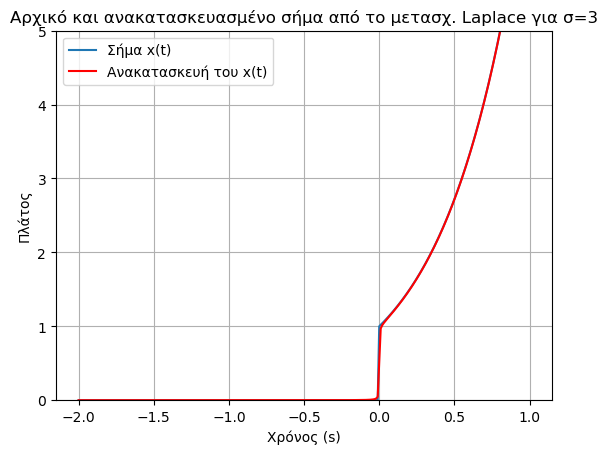

In [4]:
# Γράφημα
plt.plot(t, x, label='Σήμα x(t)')
plt.plot(t, x_est.real, 'r', label='Ανακατασκευή του x(t)')
plt.grid()
plt.legend()
plt.ylim([0, 5])                                                              # Zoom στο κομμάτι [0,5] του y'y
plt.title('Αρχικό και ανακατασκευασμένο σήμα από το μετασχ. Laplace για σ=3') # Ομορφαίνουμε
plt.xlabel('Χρόνος (s)')                                                      # Ομορφαίνουμε
plt.ylabel('Πλάτος')                                                          # Ομορφαίνουμε
plt.show()

Βλέπετε ότι παρ' όλο που το σήμα "φεύγει" στο άπειρο όταν $t \to +\infty$, εμείς μπορέσαμε να το ανακατασκευάσουμε, απλά χρειαστήκαμε ημίτονα με αύξον (αντί σταθερό) πλάτος!

---

Γράψτε κώδικα ``Python`` για να αντιστρέψετε μέσω του μετασχ. Laplace για κάποιο κατάλληλο $\sigma$ της επιλογής σας το σήμα $x(t)$ για τα παρακάτω ζεύγη:

(α') $$x(t) = -e^{-3t}u(-t) \longleftrightarrow X(s) = \frac{1}{s+3}, \: \: \sigma < -3$$
(β') $$x(t) = e^{-2t}(t) - e^{2t}u(-t) \longleftrightarrow X(s) = \frac{2s}{(s-2)(s+2)}, \: \: -2 < \sigma < 2$$

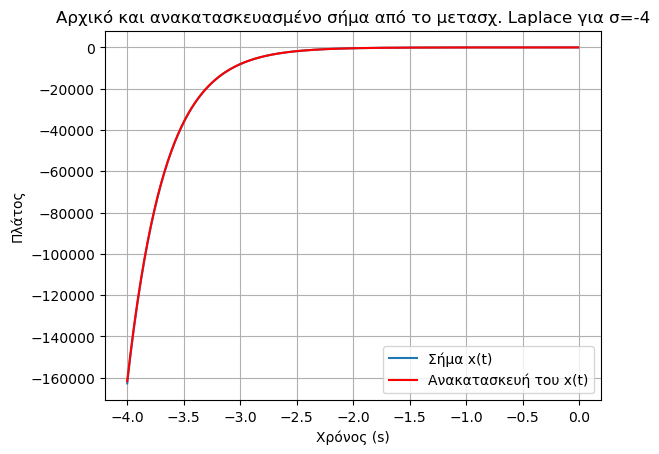

In [7]:
# (α')
# INSERT CODE HERE

# Παράμετρος α
a = -3

# Βήμα στο χρόνο
dt = 0.01
# Άξονας χρόνου [-4,0) s
t = np.arange(-4, 0, dt)

# Βήμα στη συχνότητα
df = 0.01
# Άξονας συχνότητας [-100,100] Hz
f = np.arange(-100, 100 + df, df)

# Σήμα (0 για t > 0, -exp(at) για t < 0)
x = np.where(t > 0, 0, -np.exp(a * t))

# Επιλογή μιας τιμής του σ 
sigma = -4

# Μετασχηματισμός Laplace για σ = -4
X = 1.0 / ((sigma - a) + 1j * 2 * np.pi * f)

# Δέσμευση μνήμης
x_est = np.zeros_like(t, dtype=complex)

# Σύνθεση του x(t) από μια "φέτα" του μετασχ. Laplace για σ=3
for i in range(len(f)):
    x_est += X[i] * np.exp(sigma *t) * np.exp(1j * 2 * np.pi * f[i] * t)

# Κανονικοποίηση με df λόγω του ολοκληρώματος του x(t)
x_est = df * x_est

# Γράφημα
plt.plot(t, x, label='Σήμα x(t)')
plt.plot(t, x_est.real, 'r', label='Ανακατασκευή του x(t)')
plt.grid()
plt.legend()
plt.title('Αρχικό και ανακατασκευασμένο σήμα από το μετασχ. Laplace για σ=-4') # Ομορφαίνουμε
plt.xlabel('Χρόνος (s)')                                                      # Ομορφαίνουμε
plt.ylabel('Πλάτος')                                                          # Ομορφαίνουμε
plt.show()

# END OF CODE

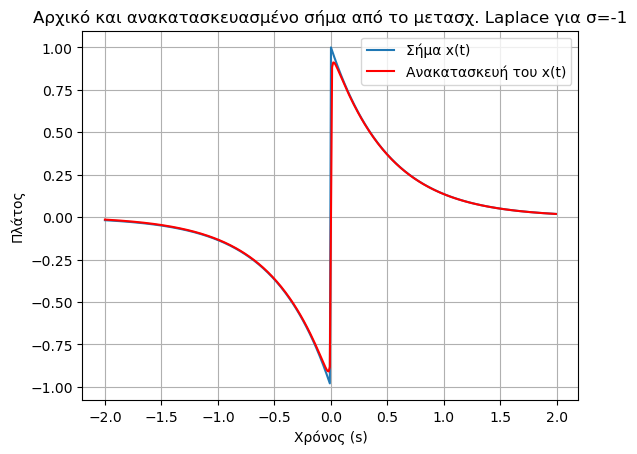

In [8]:
# (β')
# INSERT CODE HERE

# Παράμετρος α
a = -2
b = 2

# Βήμα στο χρόνο
dt = 0.01
# Άξονας χρόνου [-2,2) s
t = np.arange(-2, 2, dt)

# Βήμα στη συχνότητα
df = 0.01
# Άξονας συχνότητας [-100,100] Hz
f = np.arange(-100, 100 + df, df)

# Σήμα (exp(at) για t > 0, -exp(bt) για t < 0)
x = np.where(t > 0, np.exp(a * t), -np.exp(b * t))

# Επιλογή μιας τιμής του σ 
sigma = -1

# Μετασχηματισμός Laplace για σ = -1
X = 1.0 / ((sigma - a) + 1j * 2 * np.pi * f) + 1.0 / ((sigma - b) + 1j * 2 * np.pi * f)

# Δέσμευση μνήμης
x_est = np.zeros_like(t, dtype=complex)

# Σύνθεση του x(t) από μια "φέτα" του μετασχ. Laplace για σ=3
for i in range(len(f)):
    x_est += X[i] * np.exp(sigma *t) * np.exp(1j * 2 * np.pi * f[i] * t)

# Κανονικοποίηση με df λόγω του ολοκληρώματος του x(t)
x_est = df * x_est

# Γράφημα
plt.plot(t, x, label='Σήμα x(t)')
plt.plot(t, x_est.real, 'r', label='Ανακατασκευή του x(t)')
plt.grid()
plt.legend()
plt.title('Αρχικό και ανακατασκευασμένο σήμα από το μετασχ. Laplace για σ=-1') # Ομορφαίνουμε
plt.xlabel('Χρόνος (s)')                                                      # Ομορφαίνουμε
plt.ylabel('Πλάτος')                                                          # Ομορφαίνουμε
plt.show()

# END OF CODE

---
---